### Load Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay


### Load and Inspect Data

In [3]:
# Load Data
df = pd.read_csv("../datasets/processed/cleaned_data.csv")
print(df.shape)
display(df.head())

(129487, 25)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,type
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,4,3,4,4,5,5,25,18.0,neutral or dissatisfied,train
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,5,3,1,4,1,1,6.0,neutral or dissatisfied,train
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,4,3,4,4,4,5,0,0.0,satisfied,train
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,5,3,1,4,2,11,9.0,neutral or dissatisfied,train
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,4,4,3,3,3,0,0.0,satisfied,train


### Feature Engineering

In [32]:
engineered_df = df.copy()

# Digital Friction Index
digital_cols = ['Inflight wifi service', 'Ease of Online booking', 'Online boarding']
engineered_df['Digital_score'] = engineered_df[digital_cols].mean(axis=1)
# Physical Comfort Index
comfort_cols = ['Food and drink', 'Seat comfort', 'Inflight entertainment', 'Leg room service', 'Cleanliness']
engineered_df['Comfort_score'] = engineered_df[comfort_cols].mean(axis=1)
# Service Logistics Index
service_cols = ['Gate location', 'On-board service', 'Baggage handling', 'Checkin service', 'Inflight service']
engineered_df['Service_score'] = engineered_df[service_cols].mean(axis=1)

# Helper Binary Column for Business Class
engineered_df['Is_business_class'] = engineered_df['Class'].apply(lambda x: 1 if x == 'Business' else 0)

# Specific Business Boarding Interaction Feature
engineered_df['Biz_boarding_interaction'] = engineered_df['Is_business_class'] * engineered_df['Online boarding']

# Total Delay Feature
engineered_df['Total_delay'] = engineered_df['Departure Delay in Minutes'] + engineered_df['Arrival Delay in Minutes']

engineered_df['Haul_type'] = pd.cut(
                                engineered_df['Flight Distance'],
                                bins=[0, 800, 2500, 5000],
                                labels=['short', 'medium', 'long']
                                )

engineered_df.iloc[:5,-7:]

,Digital_score,Comfort_score,Service_score,Is_business_class,Biz_boarding_interaction,Total_delay,Haul_type
0,3.000000,4.6,3.6,0,0,43.0,short
1,3.000000,1.8,2.4,1,3,7.0,short
2,3.000000,4.6,3.6,1,5,0.0,medium
3,3.000000,2.6,3.0,1,2,20.0,short
4,3.666667,3.8,3.2,1,5,0.0,short


Grouping the 14 columns into buckets will allow for clearer insights on satisfaction predictors

<Axes: >

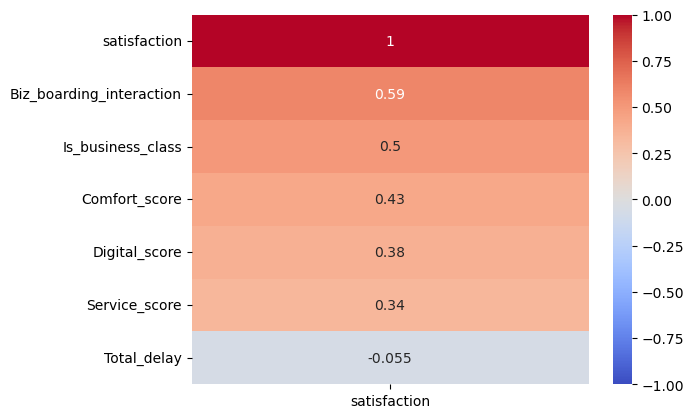

In [37]:
temp_df = engineered_df.copy()
temp_df['satisfaction'] = temp_df['satisfaction'].apply(lambda x: 1 if x == 'satisfied' else 0)

new_features = ['Digital_score', 'Comfort_score', 'Service_score', 'Is_business_class', 'Biz_boarding_interaction', 'Total_delay']

fig, ax = plt.subplots()
sns.heatmap(
    temp_df[new_features + ['satisfaction']].corr()[['satisfaction']].sort_values(by='satisfaction', ascending=False),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
)


Business passengers are more likely to be satisfied in general, but having their online boarding exprience appears to be a the strongers driver for satisfaction when compared to comfort, overall digital experience and flight service. 

Interestingly, delays has a low correlation for satisfaction. Perhaps small delays (5 mins or less) are ignored when passengers complete satisfaction surveys and extreme delays are outliers but not common enough to affect overall correlation.